# Noise Detection DINO v2

This notebook keeps the minimum workflow needed to continue developing the DINO embedding path.

Kept:
- signal-agnostic DINO input and grouping
- SigMF ground-truth patch masks
- texture and power comparison branches
- AWGN SNR sweep with compact metrics and visualizations

Removed:
- ablation chains
- alternate override stacks
- whitehat and other exploratory baselines
- positional diagnostics that were only exploratory


In [7]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage, signal
import torch
import torchvision.transforms as T
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

SIGMF_META_PATH = '/home/sat3737/holoscan_demo_workspace/test_data/SIGINT_DAY_DEMO_all_16_Emitter_noNoise.sigmf-meta'
DINOV3_LOCATION = '/home/sat3737/holoscan_demo_workspace/dinov3'
MODEL_NAME = 'dinov3_vitb16'
WEIGHTS_PATH = '/home/sat3737/holoscan_demo_workspace/dinov3_weights/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'

FFT_SIZE = 1024
NOVERLAP = 512
SAMPLE_OFFSET_S = 0.0590
DEFAULT_CHUNK_SECONDS = 1.0
USRP_SPECTROGRAM_DIR = '/tmp/usrp_spectrograms'
USE_USRP_CHUNK_DURATION = True
USE_USRP_SHAPE_MATCH = True

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(42)
print(f'Device: {DEVICE}')

Device: cpu


In [2]:
weights_file = Path(WEIGHTS_PATH)
if not weights_file.exists():
    raise FileNotFoundError(f'DINO weights not found: {weights_file}')

use_local_repo = Path(DINOV3_LOCATION).exists() and (Path(DINOV3_LOCATION) / 'hubconf.py').exists()

if use_local_repo:
    model = torch.hub.load(
        repo_or_dir=DINOV3_LOCATION,
        model=MODEL_NAME,
        source='local',
        weights=str(weights_file),
    )
else:
    model = torch.hub.load(
        repo_or_dir='facebookresearch/dinov3',
        model=MODEL_NAME,
        source='github',
        weights=str(weights_file),
    )

model.to(DEVICE).eval()
DINO_PATCH_SIZE = int(getattr(model, 'patch_size', 16))
print(f"Loaded {MODEL_NAME} (patch_size={DINO_PATCH_SIZE}) from {'local' if use_local_repo else 'github'}")


Using cache found in /home/sat3737/.cache/torch/hub/facebookresearch_dinov3_main


Loaded dinov3_vitb16 (patch_size=16) from github


In [3]:
def read_sigmf_meta(meta_path):
    meta_path = Path(meta_path)
    with meta_path.open('r') as f:
        meta = json.load(f)
    global_info = meta.get('global', {})
    captures = meta.get('captures', [])
    annotations = meta.get('annotations', [])
    return meta, global_info, captures, annotations


def _sigmf_dtype_info(datatype):
    if not datatype:
        raise ValueError('SigMF datatype is missing')

    if datatype.endswith('_le'):
        endian = '<'
        base = datatype[:-3]
    elif datatype.endswith('_be'):
        endian = '>'
        base = datatype[:-3]
    else:
        endian = '<'
        base = datatype

    is_complex = base.startswith('c')
    scalar_spec = base[1:] if is_complex else base
    if len(scalar_spec) < 2:
        raise ValueError(f'Unsupported SigMF datatype: {datatype}')

    scalar_kind = scalar_spec[0]
    bits = int(scalar_spec[1:])
    bytes_per = bits // 8
    kind_map = {'i': 'i', 'u': 'u', 'f': 'f'}
    if scalar_kind not in kind_map:
        raise ValueError(f'Unsupported SigMF datatype: {datatype}')

    dtype = np.dtype(f'{endian}{kind_map[scalar_kind]}{bytes_per}')
    return dtype, is_complex


def _load_sigmf_iq(data_path, dtype, is_complex, start_sample, count, num_channels=1, channel=0):
    data_path = Path(data_path)
    bytes_per_scalar = dtype.itemsize
    scalars_per_sample = (2 if is_complex else 1) * num_channels

    file_size = data_path.stat().st_size
    total_samples = file_size // (bytes_per_scalar * scalars_per_sample)
    if start_sample < 0 or start_sample >= total_samples:
        raise ValueError('start_sample is outside file bounds')

    if count is None:
        count = total_samples - start_sample
    count = min(count, total_samples - start_sample)

    scalar_start = start_sample * scalars_per_sample
    scalar_count = count * scalars_per_sample
    data = np.memmap(
        data_path,
        dtype=dtype,
        mode='r',
        offset=scalar_start * bytes_per_scalar,
        shape=(scalar_count,),
    )

    if is_complex:
        data = data.reshape(-1, num_channels, 2)
        i = data[:, channel, 0].astype(np.float32)
        q = data[:, channel, 1].astype(np.float32)
        samples = i + 1j * q
    else:
        data = data.reshape(-1, num_channels)
        samples = data[:, channel].astype(np.float32)

    return np.asarray(samples)


def load_sigmf_samples(meta_path, start_s=0.0, duration_s=1.0, capture_index=0, channel=0):
    _, global_info, captures, _ = read_sigmf_meta(meta_path)

    sample_rate = global_info.get('core:sample_rate')
    datatype = global_info.get('core:datatype')
    num_channels = int(global_info.get('core:num_channels', 1))
    capture = captures[capture_index] if captures else {}
    capture_start = int(capture.get('core:sample_start', 0))
    center_frequency = capture.get('core:frequency', None)

    if sample_rate is None:
        raise ValueError('SigMF metadata missing core:sample_rate')

    dtype, is_complex = _sigmf_dtype_info(datatype)
    start_sample = capture_start + int(start_s * sample_rate)
    count = int(duration_s * sample_rate) if duration_s is not None else None

    data_path = str(meta_path).replace('.sigmf-meta', '.sigmf-data')
    samples = _load_sigmf_iq(
        data_path=data_path,
        dtype=dtype,
        is_complex=is_complex,
        start_sample=start_sample,
        count=count,
        num_channels=num_channels,
        channel=channel,
    )

    params = {
        'sample_rate': float(sample_rate),
        'datatype': datatype,
        'num_channels': num_channels,
        'center_frequency': center_frequency,
    }
    return samples, params


def generate_spectrogram(iq_data, fs, nperseg=1024, noverlap=512, center_frequency=None):
    f, t, sxx = signal.spectrogram(
        iq_data,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        return_onesided=False,
    )
    sxx = np.fft.fftshift(sxx, axes=0)
    f = np.fft.fftshift(f)
    if center_frequency is not None:
        f = f + center_frequency
    sxx_db = 10.0 * np.log10(sxx + 1e-10)
    return f, t, sxx_db


def spectrogram_to_rgb(sxx_db, vmin=None, vmax=None):
    from matplotlib import colormaps

    if vmin is None:
        vmin = float(np.percentile(sxx_db, 1))
    if vmax is None:
        vmax = float(np.percentile(sxx_db, 99))

    denom = (vmax - vmin) if (vmax - vmin) > 0 else 1.0
    x = np.clip((sxx_db - vmin) / denom, 0.0, 1.0)
    rgb = (colormaps['viridis'](x)[..., :3] * 255).astype(np.uint8)
    return Image.fromarray(rgb), vmin, vmax


def infer_usrp_chunk_duration_seconds(spectrogram_dir):
    spectrogram_dir = Path(spectrogram_dir)
    if not spectrogram_dir.exists():
        return None, None

    files = sorted(spectrogram_dir.glob('spectrogram_ch*_*.pgm'))
    if len(files) < 2:
        return None, None

    ts = []
    shape = None
    for p in files:
        m = re.search(r'_(\d+)_(\d+)x(\d+)\.pgm$', p.name)
        if m is None:
            continue
        ts.append(int(m.group(1)))
        if shape is None:
            shape = (int(m.group(2)), int(m.group(3)))

    if len(ts) < 2:
        return None, shape

    ts = np.array(sorted(ts), dtype=np.int64)
    deltas_ms = np.diff(ts)
    chunk_s = float(np.median(deltas_ms) / 1000.0)
    return chunk_s, shape


def chunk_seconds_for_target_time_bins(sample_rate, target_time_bins, nperseg, noverlap):
    if target_time_bins is None or target_time_bins < 2:
        return None
    hop = nperseg - noverlap
    if hop <= 0:
        raise ValueError('nperseg must be greater than noverlap')
    required_samples = nperseg + (target_time_bins - 1) * hop
    return float(required_samples / sample_rate)


def get_overlapping_sigmf_annotations(meta_path, window_start_s, window_duration_s, capture_index=0):
    _, global_info, captures, annotations = read_sigmf_meta(meta_path)

    if not annotations:
        return []

    sample_rate = float(global_info.get('core:sample_rate'))
    capture = captures[capture_index] if captures else {}
    capture_start = int(capture.get('core:sample_start', 0))

    window_start_sample = capture_start + int(round(window_start_s * sample_rate))
    window_sample_count = int(round(window_duration_s * sample_rate))
    window_end_sample = window_start_sample + window_sample_count

    captures_sorted = sorted(
        captures,
        key=lambda c: int(c.get('core:sample_start', 0)),
    )

    def _center_frequency_for_sample(sample_idx):
        if not captures_sorted:
            return None
        chosen_cf = captures_sorted[0].get('core:frequency', None)
        for cap in captures_sorted:
            cap_start = int(cap.get('core:sample_start', 0))
            if cap_start <= sample_idx:
                chosen_cf = cap.get('core:frequency', chosen_cf)
            else:
                break
        if chosen_cf is None:
            return None
        return float(chosen_cf)

    def _to_zero_center_offset(freq_hz, center_frequency_hz):
        if freq_hz is None:
            return None

        freq_hz = float(freq_hz)
        if center_frequency_hz is None:
            return freq_hz

        if abs(freq_hz) > (2.0 * sample_rate):
            return freq_hz - float(center_frequency_hz)

        return freq_hz

    overlaps = []
    for ann in annotations:
        ann_start = ann.get('core:sample_start', None)
        ann_count = ann.get('core:sample_count', None)
        if ann_start is None or ann_count is None:
            continue

        ann_start = int(ann_start)
        ann_end = ann_start + int(ann_count)

        overlap_start = max(window_start_sample, ann_start)
        overlap_end = min(window_end_sample, ann_end)
        if overlap_end <= overlap_start:
            continue

        overlap_cf = _center_frequency_for_sample(overlap_start)

        t0 = (overlap_start - window_start_sample) / sample_rate
        t1 = (overlap_end - window_start_sample) / sample_rate

        f0 = _to_zero_center_offset(ann.get('core:freq_lower_edge', None), overlap_cf)
        f1 = _to_zero_center_offset(ann.get('core:freq_upper_edge', None), overlap_cf)

        overlaps.append({
            't0': float(t0),
            't1': float(t1),
            'f0': f0,
            'f1': f1,
            'label': str(ann.get('core:label', 'annotation')),
        })

    return overlaps


def draw_sigmf_annotation_overlays(ax, ann_list, time_max_s, freq_min_hz, freq_max_hz, legend_max_items=14):
    import matplotlib.patches as patches
    from matplotlib.lines import Line2D

    if not ann_list:
        return

    freq_span = max(freq_max_hz - freq_min_hz, 1.0)
    min_height = 0.01 * freq_span

    label_spans = {}
    for ann in ann_list:
        label = ann.get('label', 'annotation')
        label_spans[label] = label_spans.get(label, 0.0) + max(0.0, float(ann['t1']) - float(ann['t0']))

    sorted_labels = sorted(label_spans, key=lambda name: (-label_spans[name], name))
    colors = plt.cm.tab20(np.linspace(0, 1, max(20, len(sorted_labels))))
    color_by_label = {label: colors[i % len(colors)] for i, label in enumerate(sorted_labels)}

    labels_drawn = set()
    for ann in ann_list:
        x0 = float(np.clip(ann['t0'], 0.0, time_max_s))
        x1 = float(np.clip(ann['t1'], 0.0, time_max_s))
        if x1 <= x0:
            continue

        y0 = freq_min_hz if ann['f0'] is None else float(ann['f0'])
        y1 = freq_max_hz if ann['f1'] is None else float(ann['f1'])
        if y1 < y0:
            y0, y1 = y1, y0
        if (y1 < freq_min_hz) or (y0 > freq_max_hz):
            continue

        y0 = float(np.clip(y0, freq_min_hz, freq_max_hz))
        y1 = float(np.clip(y1, freq_min_hz, freq_max_hz))
        if y1 <= y0:
            y1 = min(freq_max_hz, y0 + min_height)

        color = color_by_label.get(ann['label'], (1.0, 1.0, 1.0, 1.0))
        rect = patches.Rectangle(
            (x0, y0),
            x1 - x0,
            max(y1 - y0, min_height),
            linewidth=1.5,
            edgecolor=color,
            facecolor='none',
            alpha=0.9,
        )
        ax.add_patch(rect)
        labels_drawn.add(ann['label'])

    legend_labels = [label for label in sorted_labels if label in labels_drawn][:legend_max_items]
    if not legend_labels:
        return

    handles = [
        Line2D([0], [0], color=color_by_label[label], lw=2, label=label)
        for label in legend_labels
    ]
    hidden_count = max(0, len(labels_drawn) - len(legend_labels))
    if hidden_count > 0:
        handles.append(
            Line2D([0], [0], color='white', lw=0, label=f'+{hidden_count} more labels')
        )

    legend = ax.legend(
        handles=handles,
        title='SigMF Labels',
        loc='upper left',
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        framealpha=0.9,
        fontsize=8,
        title_fontsize=9,
    )
    if legend is not None:
        legend.get_frame().set_facecolor('black')
        legend.get_frame().set_edgecolor('0.4')
        for text in legend.get_texts():
            text.set_color('white')
        legend.get_title().set_color('white')


In [4]:
def _prep_dino_image(img_rgb):
    w = (img_rgb.size[0] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
    h = (img_rgb.size[1] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
    return img_rgb.crop((0, 0, w, h))


def _extract_dino_features_from_rgb(img_rgb):
    img_rgb = _prep_dino_image(img_rgb)
    transform_local = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    x = transform_local(img_rgb).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat_local = model.get_intermediate_layers(x, n=1, reshape=True, norm=True)[0]
    feat_local = feat_local.squeeze().view(feat_local.shape[1], -1).permute(1, 0).cpu().numpy()
    gh = img_rgb.size[1] // DINO_PATCH_SIZE
    gw = img_rgb.size[0] // DINO_PATCH_SIZE
    return feat_local, gh, gw, img_rgb


def _normalize_map01_local(x, low_q=5.0, high_q=95.0):
    x = np.asarray(x, dtype=np.float32)
    vals = x[np.isfinite(x)]
    if vals.size == 0:
        return np.zeros_like(x, dtype=np.float32)
    lo = float(np.percentile(vals, low_q))
    hi = float(np.percentile(vals, high_q))
    if hi <= lo:
        hi = lo + 1e-6
    out = (x - lo) / (hi - lo)
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def _normalize_vector01(x):
    x = np.asarray(x, dtype=np.float32)
    if x.size == 0:
        return x.astype(np.float32)
    lo = float(np.min(x))
    hi = float(np.max(x))
    if hi <= lo + 1e-8:
        return np.ones_like(x, dtype=np.float32)
    return ((x - lo) / (hi - lo)).astype(np.float32)


def patch_mean_map(x_px, patch_h, patch_w):
    x_px = np.asarray(x_px, dtype=np.float32)
    bh = max(1, x_px.shape[0] // patch_h)
    bw = max(1, x_px.shape[1] // patch_w)
    h_use = patch_h * bh
    w_use = patch_w * bw
    x_crop = x_px[:h_use, :w_use]
    return x_crop.reshape(patch_h, bh, patch_w, bw).mean(axis=(1, 3)).astype(np.float32)


def dino_seed_patch_map(sxx_db_local, patch_h, patch_w):
    x_db = np.asarray(sxx_db_local, dtype=np.float32)
    p_lin = np.power(10.0, x_db / 10.0)
    p_floor = max(float(np.percentile(p_lin, 30.0)), 1e-20)
    rel_db = 10.0 * np.log10(np.maximum(p_lin, 1e-20) / p_floor)
    rel_db = np.clip(rel_db, -10.0, 25.0)

    persistence_px = ndimage.uniform_filter(rel_db, size=(1, 7), mode='nearest')
    local_contrast_px = rel_db - ndimage.uniform_filter(rel_db, size=(5, 5), mode='nearest')

    persistence_n = _normalize_map01_local(persistence_px)
    contrast_n = _normalize_map01_local(local_contrast_px)
    seed_px = (0.65 * persistence_n + 0.35 * contrast_n).astype(np.float32)
    return patch_mean_map(seed_px, patch_h, patch_w)


def _smooth_binary_label_map(label_map, iters=2, min_component_size=6):
    out = label_map.copy().astype(np.uint8)

    for _ in range(int(iters)):
        avg = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
        out = (avg >= 0.5).astype(np.uint8)

    comp, n_comp = ndimage.label(out)
    if n_comp > 0:
        sizes = ndimage.sum(out, comp, index=np.arange(1, n_comp + 1))
        small_ids = np.where(sizes < int(min_component_size))[0] + 1
        if len(small_ids) > 0:
            small_mask = np.isin(comp, small_ids)
            neigh = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
            out[small_mask] = (neigh[small_mask] >= 0.5).astype(np.uint8)

    comp_bg, n_bg = ndimage.label(out == 0)
    if n_bg > 0:
        sizes_bg = ndimage.sum(out == 0, comp_bg, index=np.arange(1, n_bg + 1))
        small_bg = np.where(sizes_bg < int(min_component_size))[0] + 1
        if len(small_bg) > 0:
            small_mask_bg = np.isin(comp_bg, small_bg)
            neigh = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
            out[small_mask_bg] = (neigh[small_mask_bg] >= 0.5).astype(np.uint8)

    return out


def _overlay_from_mask(base_img_rgb, mask_patch, alpha=0.45):
    up = Image.fromarray((mask_patch * 255).astype(np.uint8), mode='L').resize(base_img_rgb.size, Image.NEAREST)
    mask = np.array(up) >= 128
    base = np.array(base_img_rgb).astype(np.float32)
    over = base.copy()
    color_fg = np.array([60, 175, 255], dtype=np.float32)
    color_bg = np.array([255, 90, 90], dtype=np.float32)
    over[~mask] = (1 - alpha) * over[~mask] + alpha * color_bg
    over[mask] = (1 - alpha) * over[mask] + alpha * color_fg
    return over.astype(np.uint8)


def _spatial_metrics(mask_patch):
    v_dis = np.mean(mask_patch[1:, :] != mask_patch[:-1, :])
    h_dis = np.mean(mask_patch[:, 1:] != mask_patch[:, :-1])
    edge_disagreement = 0.5 * (v_dis + h_dis)
    comp_fg, n_fg = ndimage.label(mask_patch == 1)
    comp_bg, n_bg = ndimage.label(mask_patch == 0)
    return {
        'smoothness': float(1.0 - edge_disagreement),
        'edge_disagreement': float(edge_disagreement),
        'num_components_total': int(n_fg + n_bg),
        'foreground_fraction': float(mask_patch.mean()),
    }


def _normalized_patch_coords(patch_h, patch_w):
    row = np.linspace(-1.0, 1.0, patch_h, dtype=np.float32)
    col = np.linspace(-1.0, 1.0, patch_w, dtype=np.float32)
    return np.meshgrid(row, col, indexing='ij')


def _safe_corrcoef(x, y):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    if x.size == 0 or y.size == 0 or np.std(x) <= 1e-8 or np.std(y) <= 1e-8:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def _image_to_gray01(img_rgb):
    arr = np.asarray(img_rgb, dtype=np.float32)
    if arr.ndim == 3:
        arr = arr[..., 0]
    return np.clip(arr / 255.0, 0.0, 1.0).astype(np.float32)


def _spectrogram_trend_map(sxx_db_local):
    x_db = np.asarray(sxx_db_local, dtype=np.float32)
    row_sigma = max(1.0, x_db.shape[0] / 32.0)
    col_sigma = max(1.0, x_db.shape[1] / 32.0)
    row_trend = ndimage.gaussian_filter1d(np.mean(x_db, axis=1), sigma=row_sigma, mode='nearest')[:, None]
    col_trend = ndimage.gaussian_filter1d(np.mean(x_db, axis=0), sigma=col_sigma, mode='nearest')[None, :]
    return (row_trend + col_trend - float(np.mean(x_db))).astype(np.float32)


def _signed_residual_to_unit(x, q=95.0):
    x = np.asarray(x, dtype=np.float32)
    vals = np.abs(x[np.isfinite(x)])
    scale = float(np.percentile(vals, q)) if vals.size else 1.0
    scale = max(scale, 1e-6)
    return np.clip(0.5 + 0.5 * (x / scale), 0.0, 1.0).astype(np.float32)


def _positional_design_matrix(patch_h, patch_w):
    row_grid, col_grid = _normalized_patch_coords(patch_h, patch_w)
    basis = [
        np.ones(row_grid.size, dtype=np.float32),
        row_grid.reshape(-1),
        col_grid.reshape(-1),
        (row_grid ** 2).reshape(-1),
        (col_grid ** 2).reshape(-1),
        (row_grid * col_grid).reshape(-1),
        np.sin(np.pi * row_grid).reshape(-1),
        np.sin(np.pi * col_grid).reshape(-1),
        np.cos(np.pi * row_grid).reshape(-1),
        np.cos(np.pi * col_grid).reshape(-1),
        np.sin(2.0 * np.pi * row_grid).reshape(-1),
        np.sin(2.0 * np.pi * col_grid).reshape(-1),
        np.cos(2.0 * np.pi * row_grid).reshape(-1),
        np.cos(2.0 * np.pi * col_grid).reshape(-1),
        (np.sin(np.pi * row_grid) * np.cos(np.pi * col_grid)).reshape(-1),
        (np.cos(np.pi * row_grid) * np.sin(np.pi * col_grid)).reshape(-1),
    ]
    design = np.stack(basis, axis=1).astype(np.float32)
    return design, row_grid, col_grid


def _remove_positional_trend(x_embed, patch_h, patch_w, ridge=1e-3):
    x_embed = np.asarray(x_embed, dtype=np.float32)
    design, row_grid, col_grid = _positional_design_matrix(patch_h, patch_w)
    xtx = design.T @ design
    beta = np.linalg.solve(xtx + ridge * np.eye(design.shape[1], dtype=np.float32), design.T @ x_embed)
    trend = design @ beta
    detrended = (x_embed - trend).astype(np.float32)
    trend_energy_ratio = float(np.linalg.norm(trend) / max(np.linalg.norm(x_embed), 1e-6))
    return detrended, {
        'trend_energy_ratio': trend_energy_ratio,
        'row_grid': row_grid,
        'col_grid': col_grid,
        'design': design,
    }


def _remove_position_correlated_components(x_embed, patch_h, patch_w, corr_threshold=0.30):
    x_embed = np.asarray(x_embed, dtype=np.float32)
    if x_embed.ndim != 2 or min(x_embed.shape) <= 1:
        return x_embed.astype(np.float32), {'removed_component_count': 0, 'max_removed_corr': 0.0}

    design, _, _ = _positional_design_matrix(patch_h, patch_w)
    basis = design[:, 1:]
    x_centered = x_embed - x_embed.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(x_centered, full_matrices=False)
    scores = u * s[None, :]

    comp_corr = np.zeros(scores.shape[1], dtype=np.float32)
    keep = np.ones(scores.shape[1], dtype=bool)
    for idx in range(scores.shape[1]):
        y = scores[:, idx].astype(np.float32)
        y0 = y - y.mean()
        y_norm = float(np.linalg.norm(y0))
        if y_norm < 1e-8:
            continue

        max_corr = 0.0
        for col in basis.T:
            c0 = col.astype(np.float32) - float(np.mean(col))
            c_norm = float(np.linalg.norm(c0))
            if c_norm < 1e-8:
                continue
            corr = abs(float(np.dot(y0, c0) / max(y_norm * c_norm, 1e-8)))
            max_corr = max(max_corr, corr)

        comp_corr[idx] = float(max_corr)
        if max_corr >= float(corr_threshold):
            keep[idx] = False

    if not np.any(keep):
        keep[int(np.argmin(comp_corr))] = True

    scores[:, ~keep] = 0.0
    recon = (scores @ vt).astype(np.float32)
    removed = int((~keep).sum())
    max_removed_corr = float(np.max(comp_corr[~keep])) if removed > 0 else 0.0
    return recon, {
        'removed_component_count': removed,
        'max_removed_corr': max_removed_corr,
    }


def _feature_affinity_matrix(x_embed, k=8):
    x_embed = np.asarray(x_embed, dtype=np.float32)
    n = x_embed.shape[0]
    nn = NearestNeighbors(n_neighbors=min(int(k) + 1, n), metric='cosine')
    nn.fit(x_embed)
    dist, idx = nn.kneighbors(x_embed)

    valid = dist[:, 1:]
    sigma = float(np.median(valid[valid > 0])) if np.any(valid > 0) else 1.0
    sigma = max(sigma, 1e-3)

    aff = np.zeros((n, n), dtype=np.float32)
    for row in range(n):
        for col, d in zip(idx[row, 1:], dist[row, 1:]):
            w = float(np.exp(-(d ** 2) / (2.0 * sigma ** 2)))
            aff[row, col] = max(aff[row, col], w)
            aff[col, row] = max(aff[col, row], w)

    np.fill_diagonal(aff, 1.0)
    return aff


def _mutual_knn_affinity(aff, top_k=8, keep_q=0.40):
    aff = np.asarray(aff, dtype=np.float32)
    n = aff.shape[0]
    top_k = int(np.clip(top_k, 1, max(1, n - 1)))
    knn_mask = np.zeros((n, n), dtype=bool)

    for idx in range(n):
        order = np.argsort(aff[idx])[::-1]
        kept = [j for j in order if j != idx][:top_k]
        knn_mask[idx, kept] = True

    mutual = np.logical_and(knn_mask, knn_mask.T)
    vals = aff[mutual]
    vals = vals[vals > 0]
    if vals.size == 0:
        local_aff = aff.copy()
        np.fill_diagonal(local_aff, 1.0)
        return local_aff

    keep_thr = float(np.quantile(vals, float(np.clip(keep_q, 0.0, 0.95))))
    local_aff = np.where(np.logical_and(mutual, aff >= keep_thr), aff, 0.0).astype(np.float32)
    np.fill_diagonal(local_aff, 1.0)
    return local_aff


def _inject_spatial_shortcuts(local_aff, full_aff, patch_h, patch_w, spatial_weight=0.20):
    out = np.asarray(local_aff, dtype=np.float32).copy()
    full_aff = np.asarray(full_aff, dtype=np.float32)
    for row in range(patch_h):
        for col in range(patch_w):
            idx0 = row * patch_w + col
            for rr in range(max(0, row - 1), min(patch_h, row + 2)):
                for cc in range(max(0, col - 1), min(patch_w, col + 2)):
                    if rr == row and cc == col:
                        continue
                    idx1 = rr * patch_w + cc
                    base_weight = float(full_aff[idx0, idx1])
                    if base_weight <= 0.0:
                        continue
                    out[idx0, idx1] = max(out[idx0, idx1], float(spatial_weight * base_weight))
                    out[idx1, idx0] = max(out[idx1, idx0], float(spatial_weight * base_weight))
    np.fill_diagonal(out, 1.0)
    return out


def _row_normalize(mat):
    mat = np.asarray(mat, dtype=np.float32)
    row_sum = np.sum(mat, axis=1, keepdims=True)
    return mat / np.maximum(row_sum, 1e-6)


def _local_affinity_score_map(local_aff, patch_h, patch_w):
    local_aff = np.asarray(local_aff, dtype=np.float32)
    trans = _row_normalize(local_aff)
    trans2 = trans @ trans
    trans3 = trans2 @ trans

    weighted_degree = np.sum(local_aff, axis=1) - 1.0
    two_hop_return = np.diag(trans2)
    three_hop_return = np.diag(trans3)

    spatial_strength = np.zeros(local_aff.shape[0], dtype=np.float32)
    for row in range(patch_h):
        for col in range(patch_w):
            idx0 = row * patch_w + col
            vals = []
            for rr in range(max(0, row - 1), min(patch_h, row + 2)):
                for cc in range(max(0, col - 1), min(patch_w, col + 2)):
                    if rr == row and cc == col:
                        continue
                    idx1 = rr * patch_w + cc
                    vals.append(float(local_aff[idx0, idx1]))
            spatial_strength[idx0] = float(np.mean(vals)) if vals else 0.0

    score = (
        0.35 * _normalize_vector01(weighted_degree)
        + 0.30 * _normalize_vector01(two_hop_return)
        + 0.20 * _normalize_vector01(three_hop_return)
        + 0.15 * _normalize_vector01(spatial_strength)
    ).astype(np.float32)
    return _normalize_map01_local(score.reshape(patch_h, patch_w))


def _connected_affinity_components(local_aff, support_map, patch_h, patch_w, support_q=0.72, grow_q=0.58, edge_q=0.55, grow_iters=2):
    local_aff = np.asarray(local_aff, dtype=np.float32)
    support_flat = np.asarray(support_map, dtype=np.float32).reshape(-1)
    positive = local_aff[np.logical_and(local_aff > 0.0, ~np.eye(local_aff.shape[0], dtype=bool))]
    edge_thr = float(np.quantile(positive, float(np.clip(edge_q, 0.0, 0.95)))) if positive.size > 0 else 0.0
    seed_thr = float(np.quantile(support_flat, float(np.clip(support_q, 0.0, 0.99))))
    grow_thr = float(np.quantile(support_flat, float(np.clip(grow_q, 0.0, 0.95))))

    active = support_flat >= seed_thr
    eligible = support_flat >= grow_thr

    for _ in range(int(max(0, grow_iters))):
        updated = active.copy()
        for row in range(patch_h):
            for col in range(patch_w):
                idx0 = row * patch_w + col
                if active[idx0] or not eligible[idx0]:
                    continue
                linked = False
                for rr in range(max(0, row - 1), min(patch_h, row + 2)):
                    for cc in range(max(0, col - 1), min(patch_w, col + 2)):
                        if rr == row and cc == col:
                            continue
                        idx1 = rr * patch_w + cc
                        if active[idx1] and local_aff[idx0, idx1] >= edge_thr:
                            linked = True
                            break
                    if linked:
                        break
                if linked:
                    updated[idx0] = True
        if np.array_equal(updated, active):
            break
        active = updated

    active_map = active.reshape(patch_h, patch_w).astype(bool)
    structure = np.ones((3, 3), dtype=np.uint8)
    component_map, n_components = ndimage.label(active_map.astype(np.uint8), structure=structure)
    return component_map.astype(np.int32), active_map.astype(np.uint8), int(n_components), float(edge_thr)


def _component_boundary_affinity(local_aff, component_mask, patch_h, patch_w):
    comp_flat = component_mask.reshape(-1).astype(bool)
    vals = []
    for row in range(patch_h):
        for col in range(patch_w):
            idx0 = row * patch_w + col
            if not comp_flat[idx0]:
                continue
            for rr in range(max(0, row - 1), min(patch_h, row + 2)):
                for cc in range(max(0, col - 1), min(patch_w, col + 2)):
                    if rr == row and cc == col:
                        continue
                    idx1 = rr * patch_w + cc
                    if not comp_flat[idx1]:
                        vals.append(float(local_aff[idx0, idx1]))
    return float(np.mean(vals)) if vals else 0.0


def _component_summary_table(local_aff, component_map, support_map, seed_norm):
    local_aff = np.asarray(local_aff, dtype=np.float32)
    support_map = np.asarray(support_map, dtype=np.float32)
    seed_norm = np.asarray(seed_norm, dtype=np.float32)
    patch_h, patch_w = component_map.shape
    rows = []

    for comp_id in sorted(int(v) for v in np.unique(component_map) if int(v) > 0):
        comp_mask = component_map == comp_id
        idx = np.flatnonzero(comp_mask.reshape(-1))
        if idx.size == 0:
            continue

        internal = local_aff[np.ix_(idx, idx)]
        if idx.size > 1:
            triu = np.triu_indices(idx.size, k=1)
            internal_mean = float(np.mean(internal[triu])) if triu[0].size > 0 else 0.0
        else:
            internal_mean = 0.0

        boundary_mean = _component_boundary_affinity(local_aff, comp_mask, patch_h, patch_w)
        support_mean = float(np.mean(support_map[comp_mask]))
        support_peak = float(np.quantile(support_map[comp_mask], 0.90))
        seed_mean = float(np.mean(seed_norm[comp_mask]))
        smoothness = float(_spatial_metrics(comp_mask.astype(np.uint8))['smoothness'])
        rows.append({
            'cluster': int(comp_id),
            'size_fraction': float(np.mean(comp_mask)),
            'support_mean': support_mean,
            'support_peak': support_peak,
            'internal_aff': internal_mean,
            'boundary_aff': boundary_mean,
            'seed_mean': seed_mean,
            'smoothness': smoothness,
        })

    if not rows:
        return []

    support_mean_n = _normalize_vector01(np.array([row['support_mean'] for row in rows], dtype=np.float32))
    support_peak_n = _normalize_vector01(np.array([row['support_peak'] for row in rows], dtype=np.float32))
    internal_n = _normalize_vector01(np.array([row['internal_aff'] for row in rows], dtype=np.float32))
    boundary_gap = np.array([row['internal_aff'] - row['boundary_aff'] for row in rows], dtype=np.float32)
    boundary_gap_n = _normalize_vector01(boundary_gap)
    seed_n = _normalize_vector01(np.array([row['seed_mean'] for row in rows], dtype=np.float32))
    smooth_n = _normalize_vector01(np.array([row['smoothness'] for row in rows], dtype=np.float32))
    size_vals = np.array([row['size_fraction'] for row in rows], dtype=np.float32)
    size_penalty = np.clip((size_vals - 0.30) / 0.20, 0.0, 1.0).astype(np.float32)

    for idx, row in enumerate(rows):
        combined = (
            0.35 * support_mean_n[idx]
            + 0.20 * support_peak_n[idx]
            + 0.20 * internal_n[idx]
            + 0.15 * boundary_gap_n[idx]
            + 0.05 * seed_n[idx]
            + 0.05 * smooth_n[idx]
            - 0.10 * size_penalty[idx]
        )
        row['combined_score'] = float(combined)
        row['size_penalty'] = float(size_penalty[idx])

    rows.sort(key=lambda item: item['combined_score'], reverse=True)
    return rows


def _select_signal_components(component_rows, max_clusters=3):
    if not component_rows:
        return []

    best_score = float(component_rows[0]['combined_score'])
    score_floor = max(0.35, 0.72 * best_score)
    selected = []
    for row in component_rows:
        if row['combined_score'] < score_floor:
            continue
        if row['size_fraction'] > 0.45 and row['combined_score'] < 0.95 * best_score:
            continue
        selected.append(int(row['cluster']))
        if len(selected) >= int(max_clusters):
            break

    if not selected:
        selected = [int(component_rows[0]['cluster'])]
    return selected


def build_signal_agnostic_dino_input(sxx_db_local, db_min=-110.0, db_max=-40.0):
    x_db = np.asarray(sxx_db_local, dtype=np.float32)
    span = max(float(db_max - db_min), 1e-6)

    fixed_gray = np.clip((x_db - float(db_min)) / span, 0.0, 1.0).astype(np.float32)
    trend = _spectrogram_trend_map(x_db)
    detrended = (x_db - trend).astype(np.float32)

    local_mean = ndimage.uniform_filter(detrended, size=(7, 7), mode='nearest')
    local_resid = (detrended - local_mean).astype(np.float32)
    local_scale = np.sqrt(ndimage.uniform_filter(local_resid ** 2, size=(9, 9), mode='nearest') + 1e-6).astype(np.float32)
    local_z = (local_resid / np.maximum(local_scale, 1e-4)).astype(np.float32)

    abs_detrended = _normalize_map01_local(detrended, low_q=2.0, high_q=98.0)
    local_resid_n = _signed_residual_to_unit(local_z, q=95.0)
    combined = (0.70 * local_resid_n + 0.30 * abs_detrended).astype(np.float32)

    if float(np.std(combined)) < 0.02:
        combined = _normalize_map01_local(detrended, low_q=1.0, high_q=99.0)

    gray_u8 = np.clip(np.round(255.0 * combined), 0, 255).astype(np.uint8)
    img_rgb = Image.fromarray(np.stack([gray_u8, gray_u8, gray_u8], axis=-1), mode='RGB')

    row_grid, col_grid = _normalized_patch_coords(x_db.shape[0], x_db.shape[1])
    debug = {
        'variant': 'signal_agnostic_gray',
        'input_gray01': combined.astype(np.float32),
        'fixed_gray01': fixed_gray.astype(np.float32),
        'trend_db': trend.astype(np.float32),
        'detrended_db': detrended.astype(np.float32),
        'local_residual01': local_resid_n.astype(np.float32),
        'input_row_corr_px': _safe_corrcoef(combined, row_grid),
        'input_col_corr_px': _safe_corrcoef(combined, col_grid),
        'fixed_row_corr_px': _safe_corrcoef(fixed_gray, row_grid),
        'fixed_col_corr_px': _safe_corrcoef(fixed_gray, col_grid),
        'input_std_px': float(np.std(combined)),
        'fixed_std_px': float(np.std(fixed_gray)),
    }
    return img_rgb, debug


def _attach_dino_input_metadata(run, input_variant='signal_agnostic_gray', input_debug=None):
    out = dict(run)
    patch_h, patch_w = out['shape']
    input_gray = _image_to_gray01(out['input_img'])
    input_patch = patch_mean_map(input_gray, patch_h, patch_w).astype(np.float32)
    row_grid, col_grid = _normalized_patch_coords(patch_h, patch_w)
    row_profile = input_patch.mean(axis=1)
    col_profile = input_patch.mean(axis=0)
    out['input_variant'] = str(input_variant)
    out['input_patch'] = input_patch
    out['input_row_corr'] = _safe_corrcoef(input_patch, row_grid)
    out['input_col_corr'] = _safe_corrcoef(input_patch, col_grid)
    out['input_row_span'] = float(np.max(row_profile) - np.min(row_profile))
    out['input_col_span'] = float(np.max(col_profile) - np.min(col_profile))
    out['input_debug'] = input_debug if input_debug is not None else {}
    return out


def dino_region_grouping_mask(
    features_local,
    patch_h,
    patch_w,
    seed_patch=None,
    feature_knn=8,
    spatial_weight=0.35,
    score_q=0.60,
    smooth_iters=2,
    min_component_size=6,
    n_clusters=None,
    random_state=42,
):
    x = np.asarray(features_local, dtype=np.float32)
    d = min(12, x.shape[1], x.shape[0] - 1)
    if d >= 1:
        x = PCA(n_components=d, random_state=random_state).fit_transform(x)

    x_detrended, pos_info = _remove_positional_trend(x, patch_h, patch_w)
    x_detrended, comp_info = _remove_position_correlated_components(x_detrended, patch_h, patch_w)
    x_detrended = x_detrended - x_detrended.mean(axis=0, keepdims=True)
    x_detrended = x_detrended / np.maximum(np.linalg.norm(x_detrended, axis=1, keepdims=True), 1e-6)

    full_aff = _feature_affinity_matrix(x_detrended, k=feature_knn)
    local_aff = _mutual_knn_affinity(full_aff, top_k=feature_knn, keep_q=0.40)
    local_aff = _inject_spatial_shortcuts(local_aff, full_aff, patch_h, patch_w, spatial_weight=spatial_weight)

    if seed_patch is None:
        seed_patch = np.zeros((patch_h, patch_w), dtype=np.float32)
    seed_patch = np.asarray(seed_patch, dtype=np.float32)
    seed_norm = _normalize_map01_local(seed_patch)

    support_map = _local_affinity_score_map(local_aff, patch_h, patch_w)
    component_map, _active_map, n_components, edge_thr = _connected_affinity_components(
        local_aff,
        support_map,
        patch_h,
        patch_w,
        support_q=0.72,
        grow_q=0.58,
        edge_q=0.55,
        grow_iters=2,
    )

    component_rows = _component_summary_table(local_aff, component_map, support_map, seed_norm)
    selected_components = _select_signal_components(component_rows)

    if selected_components:
        selected_mask = np.isin(component_map, selected_components).astype(np.uint8)
    else:
        fallback_thr = float(np.quantile(support_map, 0.80))
        selected_mask = (support_map >= fallback_thr).astype(np.uint8)
        component_map = selected_mask.astype(np.int32)
        component_rows = []
        selected_components = [1]
        n_components = int(np.max(component_map))

    selected_mask = _smooth_binary_label_map(
        selected_mask,
        iters=smooth_iters,
        min_component_size=min_component_size,
    )

    support_selected = (support_map * selected_mask.astype(np.float32)).astype(np.float32)
    support_blur = ndimage.uniform_filter(support_selected, size=3, mode='nearest').astype(np.float32)
    support_blur = _normalize_map01_local(support_blur)

    cluster_quality = np.zeros((patch_h, patch_w), dtype=np.float32)
    if component_rows:
        score_vals = np.array([max(0.0, row['combined_score']) for row in component_rows], dtype=np.float32)
        score_vals = _normalize_vector01(score_vals)
        for row, score_val in zip(component_rows, score_vals):
            cluster_quality[component_map == int(row['cluster'])] = float(score_val)

    score_map = (
        0.70 * support_blur
        + 0.20 * cluster_quality
        + 0.10 * seed_norm
    ).astype(np.float32)
    score_map = _normalize_map01_local(score_map)

    candidate = selected_mask.astype(bool)
    candidate_scores = score_map[candidate]
    score_q = float(np.clip(score_q, 0.50, 0.95))
    if candidate_scores.size >= 4:
        thr = float(np.quantile(candidate_scores, score_q))
        mask = np.logical_and(candidate, score_map >= thr).astype(np.uint8)
        if float(mask.mean()) < 0.02:
            mask = (support_blur >= np.quantile(support_blur, 0.75)).astype(np.uint8)
            thr = float(np.quantile(score_map[mask.astype(bool)], min(score_q, 0.80))) if np.any(mask) else float(np.quantile(score_map, score_q))
    else:
        thr = float(np.quantile(score_map, score_q))
        mask = (score_map >= thr).astype(np.uint8)

    mask = _smooth_binary_label_map(mask, iters=1, min_component_size=max(2, min_component_size // 2))

    cluster_scores = {int(row['cluster']): float(row['combined_score']) for row in component_rows}
    return {
        'mask': mask.astype(np.uint8),
        'score': score_map.astype(np.float32),
        'label_map': selected_mask.astype(np.uint8),
        'cluster_map': component_map.astype(np.int32),
        'coherence_map': support_map.astype(np.float32),
        'cluster_quality_map': cluster_quality.astype(np.float32),
        'selected_support_map': support_blur.astype(np.float32),
        'threshold': float(thr),
        'cluster_scores': cluster_scores,
        'cluster_table': component_rows,
        'selected_clusters': [int(v) for v in selected_components],
        'n_clusters': int(max(1, n_components)),
        'positional_trend_ratio': float(pos_info['trend_energy_ratio']),
        'removed_position_components': int(comp_info['removed_component_count']),
        'max_removed_position_corr': float(comp_info['max_removed_corr']),
        'local_edge_threshold': float(edge_thr),
    }


def dino_grouping_from_spectrogram(
    sxx_db_local,
    db_min=-110.0,
    db_max=-40.0,
    feature_knn=8,
    spatial_weight=0.35,
    score_q=0.60,
    use_seed=True,
    smooth_iters=2,
    min_component_size=6,
    n_clusters=None,
    random_state=42,
    input_variant='signal_agnostic_gray',
):
    img_rgb, input_debug = build_signal_agnostic_dino_input(
        sxx_db_local,
        db_min=db_min,
        db_max=db_max,
    )
    feat_local, gh, gw, img_used = _extract_dino_features_from_rgb(img_rgb)
    seed_patch = dino_seed_patch_map(sxx_db_local, gh, gw) if use_seed else np.zeros((gh, gw), dtype=np.float32)
    grouped = dino_region_grouping_mask(
        feat_local,
        patch_h=gh,
        patch_w=gw,
        seed_patch=seed_patch,
        feature_knn=feature_knn,
        spatial_weight=spatial_weight,
        score_q=score_q,
        smooth_iters=smooth_iters,
        min_component_size=min_component_size,
        n_clusters=n_clusters,
        random_state=random_state,
    )
    grouped.update({
        'input_img': img_used,
        'seed_patch': seed_patch.astype(np.float32),
        'features': feat_local,
        'shape': (gh, gw),
    })
    return _attach_dino_input_metadata(grouped, input_variant=input_variant, input_debug=input_debug)


In [5]:
def _axis_edges_from_centers(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if x.size == 0:
        return np.array([0.0, 1.0], dtype=np.float32)
    if x.size == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5], dtype=np.float32)
    mids = 0.5 * (x[:-1] + x[1:])
    first = x[0] - 0.5 * (x[1] - x[0])
    last = x[-1] + 0.5 * (x[-1] - x[-2])
    return np.concatenate(([first], mids, [last])).astype(np.float32)


def _annotation_projection_freq_axis(freq_axis_hz, ann_list):
    freq_axis_hz = np.asarray(freq_axis_hz, dtype=np.float32).reshape(-1)
    if freq_axis_hz.size == 0 or not ann_list:
        return freq_axis_hz

    ann_freqs = []
    for ann in ann_list:
        for key in ('f0', 'f1'):
            value = ann.get(key, None)
            if value is not None:
                ann_freqs.append(abs(float(value)))

    if not ann_freqs:
        return freq_axis_hz

    axis_min = float(np.min(freq_axis_hz))
    axis_max = float(np.max(freq_axis_hz))
    axis_span = max(axis_max - axis_min, 1.0)
    axis_center = 0.5 * (axis_min + axis_max)
    ann_scale = float(np.percentile(np.asarray(ann_freqs, dtype=np.float32), 95.0))

    if abs(axis_center) > max(10.0 * axis_span, 10.0 * ann_scale) and ann_scale < (2.0 * axis_span):
        return (freq_axis_hz - axis_center).astype(np.float32)

    return freq_axis_hz


def sigmf_annotation_pixel_mask(ann_list, time_axis_s, freq_axis_hz):
    time_axis_s = np.asarray(time_axis_s, dtype=np.float32).reshape(-1)
    freq_axis_hz = _annotation_projection_freq_axis(freq_axis_hz, ann_list)
    mask = np.zeros((freq_axis_hz.size, time_axis_s.size), dtype=np.uint8)
    if not ann_list or time_axis_s.size == 0 or freq_axis_hz.size == 0:
        return mask

    t_edges = _axis_edges_from_centers(time_axis_s)
    f_edges = _axis_edges_from_centers(freq_axis_hz)

    for ann in ann_list:
        t0 = float(ann.get('t0', 0.0))
        t1 = float(ann.get('t1', 0.0))
        if t1 < t0:
            t0, t1 = t1, t0
        if t1 <= t_edges[0] or t0 >= t_edges[-1]:
            continue

        t_sel = np.logical_and(t_edges[:-1] < t1, t_edges[1:] > t0)
        if not np.any(t_sel):
            continue

        f0 = ann.get('f0', None)
        f1 = ann.get('f1', None)
        if f0 is None or f1 is None:
            f_sel = np.ones(freq_axis_hz.shape, dtype=bool)
        else:
            f0 = float(f0)
            f1 = float(f1)
            if f1 < f0:
                f0, f1 = f1, f0
            if f1 <= f_edges[0] or f0 >= f_edges[-1]:
                continue
            f_sel = np.logical_and(f_edges[:-1] < f1, f_edges[1:] > f0)

        if np.any(f_sel):
            mask[np.ix_(f_sel, t_sel)] = 1

    return mask


def resize_binary_mask_to_patch_grid(mask_px, patch_h, patch_w, min_coverage=0.10):
    mask_px = np.asarray(mask_px, dtype=np.float32)
    h, w = mask_px.shape
    row_edges = np.linspace(0, h, int(patch_h) + 1).astype(int)
    col_edges = np.linspace(0, w, int(patch_w) + 1).astype(int)
    mask_patch = np.zeros((int(patch_h), int(patch_w)), dtype=np.uint8)

    for i in range(int(patch_h)):
        r0, r1 = row_edges[i], row_edges[i + 1]
        if r1 <= r0:
            r1 = min(h, r0 + 1)
        for j in range(int(patch_w)):
            c0, c1 = col_edges[j], col_edges[j + 1]
            if c1 <= c0:
                c1 = min(w, c0 + 1)
            patch = mask_px[r0:r1, c0:c1]
            if patch.size == 0:
                continue
            mask_patch[i, j] = np.uint8(np.mean(patch) >= float(min_coverage))

    return mask_patch


def sigmf_annotation_patch_mask(ann_list, time_axis_s, freq_axis_hz, patch_h, patch_w, min_coverage=0.10):
    mask_px = sigmf_annotation_pixel_mask(ann_list, time_axis_s, freq_axis_hz)
    mask_patch = resize_binary_mask_to_patch_grid(
        mask_px,
        patch_h=patch_h,
        patch_w=patch_w,
        min_coverage=min_coverage,
    )
    return mask_patch.astype(np.uint8), mask_px.astype(np.uint8)


def binary_mask_metrics(pred_mask, gt_mask):
    pred = np.asarray(pred_mask, dtype=bool)
    gt = np.asarray(gt_mask, dtype=bool)
    if pred.shape != gt.shape:
        raise ValueError(f'Mask shape mismatch: pred={pred.shape}, gt={gt.shape}')

    tp = float(np.logical_and(pred, gt).sum())
    fp = float(np.logical_and(pred, np.logical_not(gt)).sum())
    fn = float(np.logical_and(np.logical_not(pred), gt).sum())
    tn = float(np.logical_and(np.logical_not(pred), np.logical_not(gt)).sum())

    precision = tp / max(tp + fp, 1.0)
    recall = tp / max(tp + fn, 1.0)
    iou = tp / max(tp + fp + fn, 1.0)
    f1 = 0.0 if (precision + recall) <= 0 else (2.0 * precision * recall / (precision + recall))
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1.0)

    return {
        'precision': precision,
        'recall': recall,
        'iou': iou,
        'f1': f1,
        'accuracy': accuracy,
        'gt_foreground_fraction': float(gt.mean()),
    }


def nonlocal_texture_recurrence_mask(img_rgb, patch_h, patch_w, patch_size, k=6, q=0.90):
    gray = np.array(img_rgb.convert('L')).astype(np.float32) / 255.0
    H = patch_h * patch_size
    W = patch_w * patch_size
    gray = gray[:H, :W]
    patches = gray.reshape(patch_h, patch_size, patch_w, patch_size).transpose(0, 2, 1, 3).reshape(-1, patch_size * patch_size)

    patches = patches - patches.mean(axis=1, keepdims=True)
    patches = patches / np.maximum(patches.std(axis=1, keepdims=True), 1e-6)

    nn = NearestNeighbors(n_neighbors=min(k + 1, patches.shape[0]), metric='cosine')
    nn.fit(patches)
    dist, _ = nn.kneighbors(patches)
    rec_score = dist[:, 1:].mean(axis=1)
    score = -rec_score.reshape(patch_h, patch_w).astype(np.float32)
    thr = float(np.quantile(score, q))
    mask = (score >= thr).astype(np.uint8)
    return mask, score, thr


def power_prior_patch_map(sxx_db_local, patch_h, patch_w):
    p_lin = np.power(10.0, np.asarray(sxx_db_local, dtype=np.float32) / 10.0)
    p_floor = max(float(np.percentile(p_lin, 30.0)), 1e-20)
    rel_db = 10.0 * np.log10(np.maximum(p_lin, 1e-20) / p_floor)
    rel_db = np.clip(rel_db, -5.0, 25.0)
    return patch_mean_map(rel_db, patch_h, patch_w)


def threshold_patch_score(score_patch, q=0.90):
    score_patch = np.asarray(score_patch, dtype=np.float32)
    thr = float(np.quantile(score_patch, q))
    return (score_patch >= thr).astype(np.uint8), thr


def robust_fixed_db_window(
    sxx_frame_db,
    low_q=1.0,
    high_q=99.0,
    min_span_db=12.0,
    floor_db=-140.0,
    ceil_db=-20.0,
):
    vals = np.asarray(sxx_frame_db, dtype=np.float32).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -110.0, -98.0

    lo = float(np.percentile(vals, low_q))
    hi = float(np.percentile(vals, high_q))
    if hi < lo:
        lo, hi = hi, lo

    lo = float(np.clip(lo, floor_db, ceil_db))
    hi = float(np.clip(hi, floor_db, ceil_db))
    span = max(hi - lo, float(min_span_db))
    span = min(span, float(ceil_db - floor_db))
    center = 0.5 * (lo + hi)
    half = 0.5 * span
    center = float(np.clip(center, floor_db + half, ceil_db - half))
    vmin = center - half
    vmax = center + half
    if vmax <= vmin:
        vmax = vmin + 1.0
    return float(vmin), float(vmax)


def estimate_original_noise_floor_db(
    sxx_db_local,
    q=20.0,
    trim_high_q=80.0,
    floor_db_min=-140.0,
    floor_db_max=-20.0,
):
    vals = np.asarray(sxx_db_local, dtype=np.float32).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -100.0

    hi_cap = float(np.percentile(vals, trim_high_q))
    vals_trim = vals[vals <= hi_cap]
    if vals_trim.size < 32:
        vals_trim = vals

    floor_db = float(np.percentile(vals_trim, q))
    return float(np.clip(floor_db, floor_db_min, floor_db_max))


def estimate_original_snr_from_iq(iq_clean, noise_floor_db):
    p_total = float(np.mean(np.abs(iq_clean.astype(np.complex64)) ** 2))
    p_noise = float(10.0 ** (noise_floor_db / 10.0))
    p_signal = max(p_total - p_noise, 1e-20)
    snr_db = float(10.0 * np.log10(p_signal / max(p_noise, 1e-20)))
    return p_signal, p_noise, p_total, snr_db


def add_awgn_for_target_snr(iq_clean, p_signal_est, p_noise_orig_est, target_snr_db, rng):
    target_linear = float(10.0 ** (target_snr_db / 10.0))
    p_noise_total_target = p_signal_est / max(target_linear, 1e-20)
    p_noise_add = max(p_noise_total_target - p_noise_orig_est, 0.0)

    sigma = np.sqrt(p_noise_add / 2.0)
    awgn = (
        rng.normal(0.0, sigma, size=iq_clean.shape) + 1j * rng.normal(0.0, sigma, size=iq_clean.shape)
    ).astype(np.complex64)

    y = iq_clean.astype(np.complex64) + awgn
    p_noise_total_est = p_noise_orig_est + p_noise_add
    actual_snr_est_db = float(10.0 * np.log10(max(p_signal_est, 1e-20) / max(p_noise_total_est, 1e-20)))
    return y, float(p_noise_add), float(p_noise_total_est), actual_snr_est_db


def hybrid_weights_from_snr(snr_db, texture_snr_min=-15.0, texture_snr_max=20.0, power_weight=0.20):
    alpha = float(np.clip(
        (snr_db - texture_snr_min) / max(texture_snr_max - texture_snr_min, 1e-6),
        0.0,
        1.0,
    ))
    w_tex = 0.28 + 0.30 * alpha
    w_dino = 0.52 - 0.22 * alpha
    w_power = float(power_weight)
    s = w_tex + w_dino + w_power
    return float(w_tex / s), float(w_dino / s), float(w_power / s)


def hybrid_fusion_from_components(texture_score_patch, dino_score_patch, power_score_patch, snr_db, q=0.90):
    tex_n = _normalize_map01_local(texture_score_patch, 5.0, 95.0)
    dino_n = _normalize_map01_local(dino_score_patch, 5.0, 95.0)
    power_n = _normalize_map01_local(power_score_patch, 5.0, 95.0)

    w_tex, w_dino, w_power = hybrid_weights_from_snr(snr_db)
    tex_c = (w_tex * tex_n).astype(np.float32)
    dino_c = (w_dino * dino_n).astype(np.float32)
    power_c = (w_power * power_n).astype(np.float32)

    hybrid_score = (tex_c + dino_c + power_c).astype(np.float32)
    thr = float(np.quantile(hybrid_score, q))
    hybrid_mask = (hybrid_score >= thr).astype(np.uint8)

    return {
        'hybrid_score': hybrid_score,
        'hybrid_mask': hybrid_mask,
        'hybrid_threshold': thr,
        'w_texture': w_tex,
        'w_dino': w_dino,
        'w_power': w_power,
        'texture_contrib': tex_c,
        'dino_contrib': dino_c,
        'power_contrib': power_c,
    }


def load_chunk_for_file(meta_path, start_s, duration_s):
    iq_local, params_local = load_sigmf_samples(
        meta_path,
        start_s=start_s,
        duration_s=duration_s,
        capture_index=0,
        channel=0,
    )
    fs_local = float(params_local['sample_rate'])
    cf_local = params_local.get('center_frequency', None)
    return iq_local.astype(np.complex64), fs_local, cf_local


In [13]:
def sigmf_annotation_patch_mask(ann_list, time_axis_s, freq_axis_hz, patch_h, patch_w, min_coverage=0.10):
    mask_px = sigmf_annotation_pixel_mask(ann_list, time_axis_s, freq_axis_hz)
    mask_px = np.asarray(mask_px, dtype=np.uint8)
    h_px, w_px = mask_px.shape
    row_edges = np.linspace(0, h_px, int(patch_h) + 1).astype(int)
    col_edges = np.linspace(0, w_px, int(patch_w) + 1).astype(int)
    mask_patch = np.zeros((int(patch_h), int(patch_w)), dtype=np.uint8)

    for i in range(int(patch_h)):
        r0, r1 = row_edges[i], row_edges[i + 1]
        if r1 <= r0:
            r1 = min(h_px, r0 + 1)
        for j in range(int(patch_w)):
            c0, c1 = col_edges[j], col_edges[j + 1]
            if c1 <= c0:
                c1 = min(w_px, c0 + 1)
            if np.any(mask_px[r0:r1, c0:c1]):
                mask_patch[i, j] = 1

    return mask_patch.astype(np.uint8), mask_px.astype(np.uint8)

print('Using any-overlap GT patch projection so thin SigMF boxes survive DINO patching.')

Using any-overlap GT patch projection so thin SigMF boxes survive DINO patching.


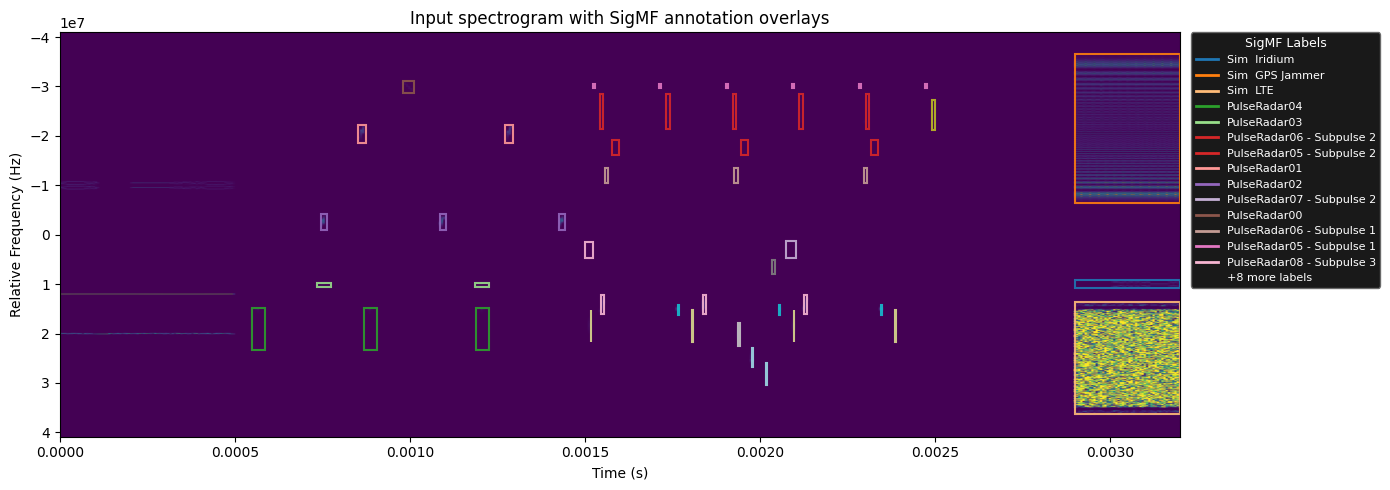

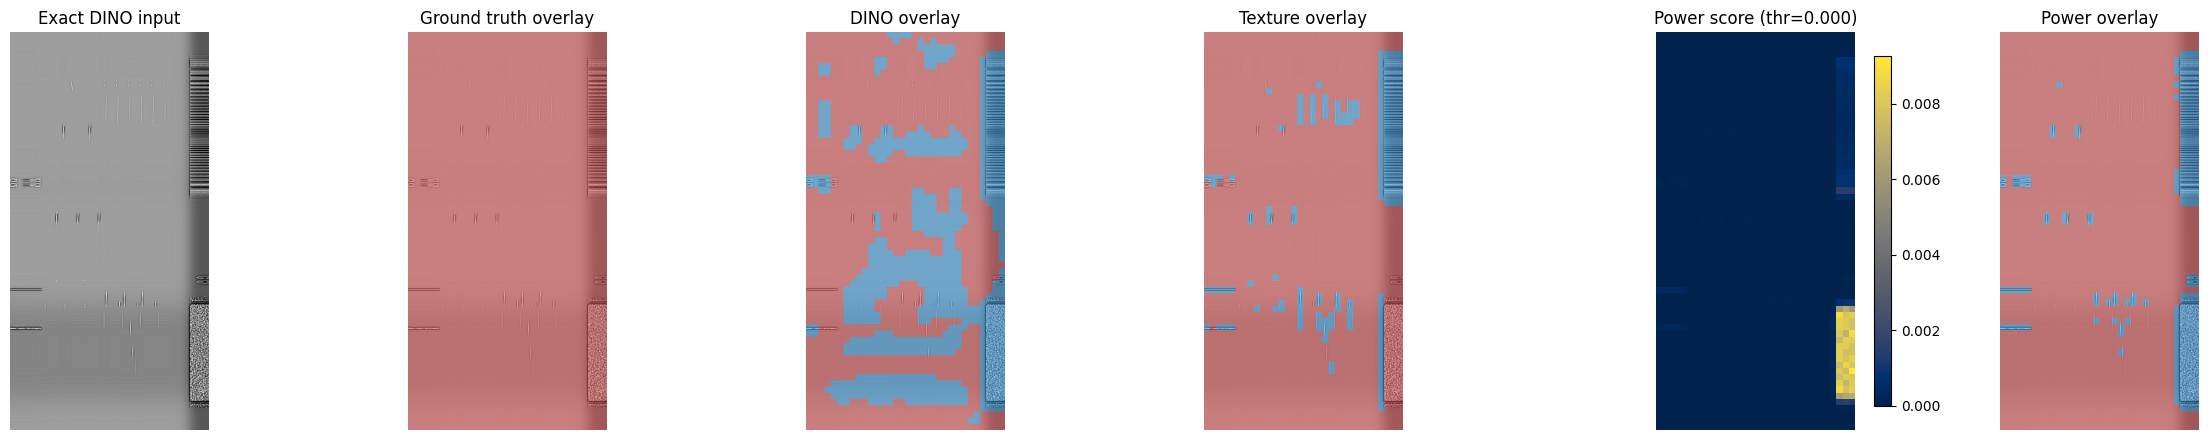

SigMF: /home/sat3737/holoscan_demo_workspace/test_data/SIGINT_DAY_DEMO_all_16_Emitter_noNoise.sigmf-meta
Preview start: 0.059000 s
Using chunk duration: 0.003206 s
Patch grid: 64 x 32


,iou,f1,precision,recall,gt_foreground_fraction
method,,,,,
dino,0.0,0.0,0.0,0.0,0.0
texture,0.0,0.0,0.0,0.0,0.0
power,0.0,0.0,0.0,0.0,0.0


In [14]:
sigmf_path = Path(SIGMF_META_PATH)
if not sigmf_path.exists():
    candidates = sorted(Path('/home/sat3737/holoscan_demo_workspace').rglob('*.sigmf-meta'))
    if not candidates:
        raise FileNotFoundError('No .sigmf-meta files found in workspace')
    sigmf_path = candidates[0]
    print(f'Using first discovered SigMF file: {sigmf_path}')

_, _, _, configured_annotations = read_sigmf_meta(sigmf_path)
if len(configured_annotations) == 0:
    annotated_candidates = []
    for candidate in sorted(Path('/home/sat3737/holoscan_demo_workspace').rglob('*.sigmf-meta')):
        try:
            _, _, _, candidate_annotations = read_sigmf_meta(candidate)
        except Exception:
            continue
        if candidate_annotations:
            annotated_candidates.append(Path(candidate))
    if annotated_candidates:
        sigmf_path = annotated_candidates[0]
        print(f'Configured SigMF has no annotations, switching to annotated file: {sigmf_path}')

usrp_chunk_s, usrp_shape = infer_usrp_chunk_duration_seconds(USRP_SPECTROGRAM_DIR)
chunk_seconds = DEFAULT_CHUNK_SECONDS
target_time_bins = None
shape_matched_chunk_s = None
if usrp_shape is not None:
    target_time_bins = int(max(usrp_shape))

if USE_USRP_SHAPE_MATCH and (target_time_bins is not None):
    _, probe_params = load_sigmf_samples(
        sigmf_path,
        start_s=SAMPLE_OFFSET_S,
        duration_s=0.01,
        capture_index=0,
        channel=0,
    )
    shape_matched_chunk_s = chunk_seconds_for_target_time_bins(
        sample_rate=probe_params['sample_rate'],
        target_time_bins=target_time_bins,
        nperseg=FFT_SIZE,
        noverlap=NOVERLAP,
    )
    if shape_matched_chunk_s is not None:
        chunk_seconds = shape_matched_chunk_s
elif USE_USRP_CHUNK_DURATION and (usrp_chunk_s is not None):
    chunk_seconds = usrp_chunk_s

window_start_s = float(SAMPLE_OFFSET_S)
_, global_info, _, annotations = read_sigmf_meta(sigmf_path)
ann_overlaps = get_overlapping_sigmf_annotations(
    meta_path=sigmf_path,
    window_start_s=window_start_s,
    window_duration_s=chunk_seconds,
    capture_index=0,
    )
if (not ann_overlaps) and annotations:
    sample_rate = float(global_info.get('core:sample_rate'))
    ann0 = annotations[0]
    ann0_start_s = int(ann0.get('core:sample_start', 0)) / sample_rate
    window_start_s = max(0.0, ann0_start_s - 0.25 * chunk_seconds)
    ann_overlaps = get_overlapping_sigmf_annotations(
        meta_path=sigmf_path,
        window_start_s=window_start_s,
        window_duration_s=chunk_seconds,
        capture_index=0,
    )
    print(f'Adjusted preview window to annotation-bearing start: {window_start_s:.6f} s')

iq, params = load_sigmf_samples(
    sigmf_path,
    start_s=window_start_s,
    duration_s=chunk_seconds,
    capture_index=0,
    channel=0,
    )

fs = params['sample_rate']
center_frequency = params['center_frequency']
f, t, sxx_db = generate_spectrogram(iq, fs=fs, nperseg=FFT_SIZE, noverlap=NOVERLAP, center_frequency=center_frequency)
spec_img, _, _ = spectrogram_to_rgb(sxx_db)

dino_vmin, dino_vmax = robust_fixed_db_window(sxx_db)
dino_preview = dino_grouping_from_spectrogram(
    sxx_db,
    db_min=dino_vmin,
    db_max=dino_vmax,
    feature_knn=8,
    spatial_weight=0.35,
    score_q=0.60,
    use_seed=True,
    smooth_iters=2,
    min_component_size=6,
    n_clusters=4,
    random_state=42,
    input_variant='signal_agnostic_gray_preview',
)

gh, gw = dino_preview['shape']
gt_patch, gt_px = sigmf_annotation_patch_mask(
    ann_overlaps,
    time_axis_s=t,
    freq_axis_hz=f,
    patch_h=gh,
    patch_w=gw,
    min_coverage=0.10,
)

texture_mask, texture_score, texture_thr = nonlocal_texture_recurrence_mask(
    spec_img,
    patch_h=gh,
    patch_w=gw,
    patch_size=DINO_PATCH_SIZE,
    k=6,
    q=0.90,
)
power_score = power_prior_patch_map(sxx_db, gh, gw)
power_mask, power_thr = threshold_patch_score(power_score, q=0.90)

preview_df = pd.DataFrame([
    {'method': 'dino', **binary_mask_metrics(dino_preview['mask'], gt_patch)},
    {'method': 'texture', **binary_mask_metrics(texture_mask, gt_patch)},
    {'method': 'power', **binary_mask_metrics(power_mask, gt_patch)},
]).set_index('method')

freq_axis = f if center_frequency is None else (f - float(center_frequency))
time_max_s = float(t[-1]) if len(t) > 0 else float(chunk_seconds)
freq_min_hz = float(np.min(freq_axis))
freq_max_hz = float(np.max(freq_axis))

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(
    spec_img,
    aspect='auto',
    origin='lower',
    extent=[0.0, time_max_s, freq_min_hz, freq_max_hz],
)
ax.set_ylim(freq_max_hz, freq_min_hz)
ax.set_title('Input spectrogram with SigMF annotation overlays')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Relative Frequency (Hz)' if center_frequency is not None else 'Frequency (Hz)')
if ann_overlaps:
    draw_sigmf_annotation_overlays(
        ax,
        ann_overlaps,
        time_max_s=time_max_s,
        freq_min_hz=freq_min_hz,
        freq_max_hz=freq_max_hz,
    )
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 6, figsize=(24, 4.5))
ax[0].imshow(dino_preview['input_img'])
ax[0].set_title('Exact DINO input')
ax[1].imshow(_overlay_from_mask(dino_preview['input_img'], gt_patch))
ax[1].set_title('Ground truth overlay')
ax[2].imshow(_overlay_from_mask(dino_preview['input_img'], dino_preview['mask']))
ax[2].set_title('DINO overlay')
ax[3].imshow(_overlay_from_mask(dino_preview['input_img'], texture_mask))
ax[3].set_title('Texture overlay')
im4 = ax[4].imshow(power_score, cmap='cividis')
ax[4].set_title(f'Power score (thr={power_thr:.3f})')
plt.colorbar(im4, ax=ax[4], fraction=0.046)
ax[5].imshow(_overlay_from_mask(dino_preview['input_img'], power_mask))
ax[5].set_title('Power overlay')
for axes in ax:
    axes.axis('off')
plt.tight_layout()
plt.show()

print(f'SigMF: {sigmf_path}')
print(f'Preview start: {window_start_s:.6f} s')
print(f'Using chunk duration: {chunk_seconds:.6f} s')
print(f'Patch grid: {gh} x {gw}')
display(preview_df[['iou', 'f1', 'precision', 'recall', 'gt_foreground_fraction']])

In [16]:
freq_axis_for_gt = f if center_frequency is None else (f - float(center_frequency))
gt_patch, gt_px = sigmf_annotation_patch_mask(
    ann_overlaps,
    time_axis_s=t,
    freq_axis_hz=freq_axis_for_gt,
    patch_h=gh,
    patch_w=gw,
    min_coverage=0.10,
)
preview_df = pd.DataFrame([
    {'method': 'dino', **binary_mask_metrics(dino_preview['mask'], gt_patch)},
    {'method': 'texture', **binary_mask_metrics(texture_mask, gt_patch)},
    {'method': 'power', **binary_mask_metrics(power_mask, gt_patch)},
]).set_index('method')
print('Updated preview GT metrics using relative frequency axis for patch projection.')
display(preview_df[['iou', 'f1', 'precision', 'recall', 'gt_foreground_fraction']])

Updated preview GT metrics using relative frequency axis for patch projection.


,iou,f1,precision,recall,gt_foreground_fraction
method,,,,,
dino,0.283908,0.442256,0.344972,0.615960,0.195801
texture,0.460241,0.630363,0.931707,0.476309,0.195801
power,0.446301,0.617162,0.912195,0.466334,0.195801


In [12]:
SNR_SWEEP_DB = list(range(30, -41, -10))
TEXTURE_Q = 0.90
TEXTURE_K = 6
POWER_Q = 0.90

DINO_GROUP_K = 8
DINO_GROUP_SPATIAL_WEIGHT = 0.35
DINO_GROUP_SCORE_Q = 0.60

NOISE_SEED = 42

sweep_meta_path = sigmf_path
sweep_start_s = float(SAMPLE_OFFSET_S)
iq_clean, sweep_fs, sweep_center_frequency = load_chunk_for_file(
    meta_path=sweep_meta_path,
    start_s=sweep_start_s,
    duration_s=chunk_seconds,
)

_, _, sxx_orig_db = generate_spectrogram(
    iq_clean,
    fs=sweep_fs,
    nperseg=FFT_SIZE,
    noverlap=NOVERLAP,
    center_frequency=sweep_center_frequency,
)
orig_noise_floor_db = estimate_original_noise_floor_db(sxx_orig_db)
p_signal_est, p_noise_orig_est, p_total_est, orig_snr_db = estimate_original_snr_from_iq(
    iq_clean,
    orig_noise_floor_db,
)

dino_vmin, dino_vmax = robust_fixed_db_window(sxx_orig_db)
gt_ann_sweep = get_overlapping_sigmf_annotations(
    sweep_meta_path,
    window_start_s=sweep_start_s,
    window_duration_s=chunk_seconds,
    capture_index=0,
)

rng = np.random.default_rng(NOISE_SEED)
gt_patch_cache = {}
snr_results = []

for snr_db in SNR_SWEEP_DB:
    noisy_iq, p_noise_added, p_noise_total_est, actual_snr_db = add_awgn_for_target_snr(
        iq_clean=iq_clean,
        p_signal_est=p_signal_est,
        p_noise_orig_est=p_noise_orig_est,
        target_snr_db=snr_db,
        rng=rng,
    )

    f_snr, t_snr, sxx_snr_db = generate_spectrogram(
        noisy_iq,
        fs=sweep_fs,
        nperseg=FFT_SIZE,
        noverlap=NOVERLAP,
        center_frequency=sweep_center_frequency,
    )

    spec_model_img, _, _ = spectrogram_to_rgb(sxx_snr_db)
    dino_group = dino_grouping_from_spectrogram(
        sxx_snr_db,
        db_min=dino_vmin,
        db_max=dino_vmax,
        feature_knn=DINO_GROUP_K,
        spatial_weight=DINO_GROUP_SPATIAL_WEIGHT,
        score_q=DINO_GROUP_SCORE_Q,
        use_seed=True,
        smooth_iters=2,
        min_component_size=6,
        n_clusters=4,
        random_state=42,
        input_variant='signal_agnostic_gray_sweep',
    )

    gh_snr, gw_snr = dino_group['shape']
    shape = (gh_snr, gw_snr)
    if shape not in gt_patch_cache:
        gt_patch_cache[shape], _ = sigmf_annotation_patch_mask(
            gt_ann_sweep,
            time_axis_s=t_snr,
            freq_axis_hz=f_snr,
            patch_h=gh_snr,
            patch_w=gw_snr,
            min_coverage=0.10,
        )
    gt_patch = gt_patch_cache[shape].astype(np.uint8)

    texture_mask, texture_score, texture_thr = nonlocal_texture_recurrence_mask(
        spec_model_img,
        patch_h=gh_snr,
        patch_w=gw_snr,
        patch_size=DINO_PATCH_SIZE,
        k=TEXTURE_K,
        q=TEXTURE_Q,
    )
    power_score = power_prior_patch_map(sxx_snr_db, gh_snr, gw_snr)
    power_mask, power_thr = threshold_patch_score(power_score, q=POWER_Q)
    hybrid = hybrid_fusion_from_components(
        texture_score_patch=texture_score,
        dino_score_patch=dino_group['score'],
        power_score_patch=power_score,
        snr_db=actual_snr_db,
        q=0.90,
    )

    dino_metrics = binary_mask_metrics(dino_group['mask'], gt_patch)
    texture_metrics = binary_mask_metrics(texture_mask, gt_patch)
    power_metrics = binary_mask_metrics(power_mask, gt_patch)
    hybrid_metrics = binary_mask_metrics(hybrid['hybrid_mask'], gt_patch)

    snr_results.append({
        'snr_db': snr_db,
        'actual_snr_db': actual_snr_db,
        'signal_power_est': p_signal_est,
        'noise_power_orig_est': p_noise_orig_est,
        'noise_power_added': p_noise_added,
        'noise_power_total_est': p_noise_total_est,
        'orig_snr_db': orig_snr_db,
        'orig_noise_floor_db': orig_noise_floor_db,
        'shape': shape,
        'spectrogram_db': sxx_snr_db,
        'spec_img': dino_group['input_img'],
        'gt_mask': gt_patch,
        'dino_mask': dino_group['mask'],
        'dino_score_map': dino_group['score'],
        'dino_threshold': dino_group['threshold'],
        'dino_input_patch_map': dino_group['input_patch'],
        'dino_input_row_corr': dino_group['input_row_corr'],
        'dino_input_col_corr': dino_group['input_col_corr'],
        'dino_positional_trend_ratio': dino_group['positional_trend_ratio'],
        'dino_removed_position_components': dino_group.get('removed_position_components', 0),
        'texture_mask': texture_mask,
        'texture_score_map': texture_score,
        'texture_threshold': texture_thr,
        'power_mask': power_mask,
        'power_score_map': power_score,
        'power_threshold': power_thr,
        'hybrid_mask': hybrid['hybrid_mask'],
        'hybrid_score_map': hybrid['hybrid_score'],
        'hybrid_threshold': hybrid['hybrid_threshold'],
        'hybrid_w_texture': hybrid['w_texture'],
        'hybrid_w_dino': hybrid['w_dino'],
        'hybrid_w_power': hybrid['w_power'],
        'texture_contrib_map': hybrid['texture_contrib'],
        'dino_contrib_map': hybrid['dino_contrib'],
        'power_contrib_map': hybrid['power_contrib'],
        'gt_metrics': _spatial_metrics(gt_patch),
        'dino_metrics': dino_metrics,
        'texture_metrics': texture_metrics,
        'power_metrics': power_metrics,
        'hybrid_metrics': hybrid_metrics,
    })

snr_eval_rows = []
for r in snr_results:
    snr_eval_rows.append({
        'snr_db': r['snr_db'],
        'actual_snr_db': r['actual_snr_db'],
        'gt_foreground_fraction': r['gt_metrics']['foreground_fraction'],
        'dino_iou': r['dino_metrics']['iou'],
        'dino_f1': r['dino_metrics']['f1'],
        'texture_iou': r['texture_metrics']['iou'],
        'texture_f1': r['texture_metrics']['f1'],
        'power_iou': r['power_metrics']['iou'],
        'power_f1': r['power_metrics']['f1'],
        'hybrid_iou': r['hybrid_metrics']['iou'],
        'hybrid_f1': r['hybrid_metrics']['f1'],
        'dino_foreground_fraction': r['dino_metrics']['gt_foreground_fraction'] if False else float(r['dino_mask'].mean()),
        'texture_foreground_fraction': float(r['texture_mask'].mean()),
        'power_foreground_fraction': float(r['power_mask'].mean()),
        'hybrid_foreground_fraction': float(r['hybrid_mask'].mean()),
        'dino_input_row_corr': r['dino_input_row_corr'],
        'dino_input_col_corr': r['dino_input_col_corr'],
        'dino_positional_trend_ratio': r['dino_positional_trend_ratio'],
        'dino_removed_position_components': r['dino_removed_position_components'],
    })

snr_eval_df = pd.DataFrame(snr_eval_rows).sort_values('snr_db', ascending=False)
print('SNR sweep evaluation vs SigMF annotation boxes:')
display(snr_eval_df)


SNR sweep evaluation vs SigMF annotation boxes:


,snr_db,actual_snr_db,gt_foreground_fraction,dino_iou,dino_f1,texture_iou,texture_f1,power_iou,power_f1,hybrid_iou,hybrid_f1,dino_foreground_fraction,texture_foreground_fraction,power_foreground_fraction,hybrid_foreground_fraction,dino_input_row_corr,dino_input_col_corr,dino_positional_trend_ratio,dino_removed_position_components
0,30,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.358398,0.100098,0.100098,0.100098,-0.245967,-0.450166,0.914095,0
1,20,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.354492,0.100098,0.100098,0.100098,-0.245543,-0.447509,0.903463,0
2,10,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.349609,0.100098,0.100098,0.100098,-0.243930,-0.450744,0.935518,0
3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.321777,0.100098,0.100098,0.100098,-0.257953,-0.434823,0.964208,0
4,-10,-10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.309082,0.100098,0.100098,0.100098,-0.121887,-0.149434,0.979031,0
5,-20,-20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.292969,0.100098,0.100098,0.100098,0.002785,-0.007713,0.987810,0
6,-30,-30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.288086,0.100098,0.100098,0.100098,0.007474,0.011222,0.986761,0
7,-40,-40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.296387,0.100098,0.100098,0.100098,-0.016903,0.000187,0.987801,0


In [17]:
freq_axis_sweep = f_snr if sweep_center_frequency is None else (f_snr - float(sweep_center_frequency))
gt_patch_cache = {}
snr_eval_rows = []
for r in snr_results:
    shape = tuple(r['shape'])
    if shape not in gt_patch_cache:
        gt_patch_cache[shape], _ = sigmf_annotation_patch_mask(
            gt_ann_sweep,
            time_axis_s=t_snr,
            freq_axis_hz=freq_axis_sweep,
            patch_h=shape[0],
            patch_w=shape[1],
            min_coverage=0.10,
        )
    gt_patch = gt_patch_cache[shape].astype(np.uint8)
    r['gt_mask'] = gt_patch
    r['dino_metrics'] = binary_mask_metrics(r['dino_mask'], gt_patch)
    r['texture_metrics'] = binary_mask_metrics(r['texture_mask'], gt_patch)
    r['power_metrics'] = binary_mask_metrics(r['power_mask'], gt_patch)
    r['hybrid_metrics'] = binary_mask_metrics(r['hybrid_mask'], gt_patch)
    r['gt_metrics'] = _spatial_metrics(gt_patch)

    snr_eval_rows.append({
        'snr_db': r['snr_db'],
        'actual_snr_db': r['actual_snr_db'],
        'gt_foreground_fraction': r['gt_metrics']['foreground_fraction'],
        'dino_iou': r['dino_metrics']['iou'],
        'dino_f1': r['dino_metrics']['f1'],
        'texture_iou': r['texture_metrics']['iou'],
        'texture_f1': r['texture_metrics']['f1'],
        'power_iou': r['power_metrics']['iou'],
        'power_f1': r['power_metrics']['f1'],
        'hybrid_iou': r['hybrid_metrics']['iou'],
        'hybrid_f1': r['hybrid_metrics']['f1'],
        'dino_foreground_fraction': float(r['dino_mask'].mean()),
        'texture_foreground_fraction': float(r['texture_mask'].mean()),
        'power_foreground_fraction': float(r['power_mask'].mean()),
        'hybrid_foreground_fraction': float(r['hybrid_mask'].mean()),
        'dino_input_row_corr': r['dino_input_row_corr'],
        'dino_input_col_corr': r['dino_input_col_corr'],
        'dino_positional_trend_ratio': r['dino_positional_trend_ratio'],
        'dino_removed_position_components': r['dino_removed_position_components'],
    })

snr_eval_df = pd.DataFrame(snr_eval_rows).sort_values('snr_db', ascending=False)
print('Recomputed SNR sweep evaluation using relative frequency axis for GT patch projection:')
display(snr_eval_df)

Recomputed SNR sweep evaluation using relative frequency axis for GT patch projection:


,snr_db,actual_snr_db,gt_foreground_fraction,dino_iou,dino_f1,texture_iou,texture_f1,power_iou,power_f1,hybrid_iou,hybrid_f1,dino_foreground_fraction,texture_foreground_fraction,power_foreground_fraction,hybrid_foreground_fraction,dino_input_row_corr,dino_input_col_corr,dino_positional_trend_ratio,dino_removed_position_components
0,30,30.0,0.195801,0.270997,0.426432,0.460241,0.630363,0.446301,0.617162,0.463768,0.633663,0.358398,0.100098,0.100098,0.100098,-0.245967,-0.450166,0.914095,0
1,20,20.0,0.195801,0.290951,0.450754,0.463768,0.633663,0.446301,0.617162,0.453237,0.623762,0.354492,0.100098,0.100098,0.100098,-0.245543,-0.447509,0.903463,0
2,10,10.0,0.195801,0.285386,0.444047,0.453237,0.623762,0.446301,0.617162,0.463768,0.633663,0.349609,0.100098,0.100098,0.100098,-0.243930,-0.450744,0.935518,0
3,0,0.0,0.195801,0.248528,0.398113,0.281184,0.438944,0.399538,0.570957,0.311688,0.475248,0.321777,0.100098,0.100098,0.100098,-0.257953,-0.434823,0.964208,0
4,-10,-10.0,0.195801,0.222222,0.363636,0.070671,0.132013,0.257261,0.409241,0.128492,0.227723,0.309082,0.100098,0.100098,0.100098,-0.121887,-0.149434,0.979031,0
5,-20,-20.0,0.195801,0.140091,0.245754,0.076377,0.141914,0.156489,0.270627,0.082143,0.151815,0.292969,0.100098,0.100098,0.100098,0.002785,-0.007713,0.987810,0
6,-30,-30.0,0.195801,0.104794,0.189707,0.078292,0.145215,0.052083,0.099010,0.044828,0.085809,0.288086,0.100098,0.100098,0.100098,0.007474,0.011222,0.986761,0
7,-40,-40.0,0.195801,0.126257,0.224206,0.078292,0.145215,0.068783,0.128713,0.078292,0.145215,0.296387,0.100098,0.100098,0.100098,-0.016903,0.000187,0.987801,0


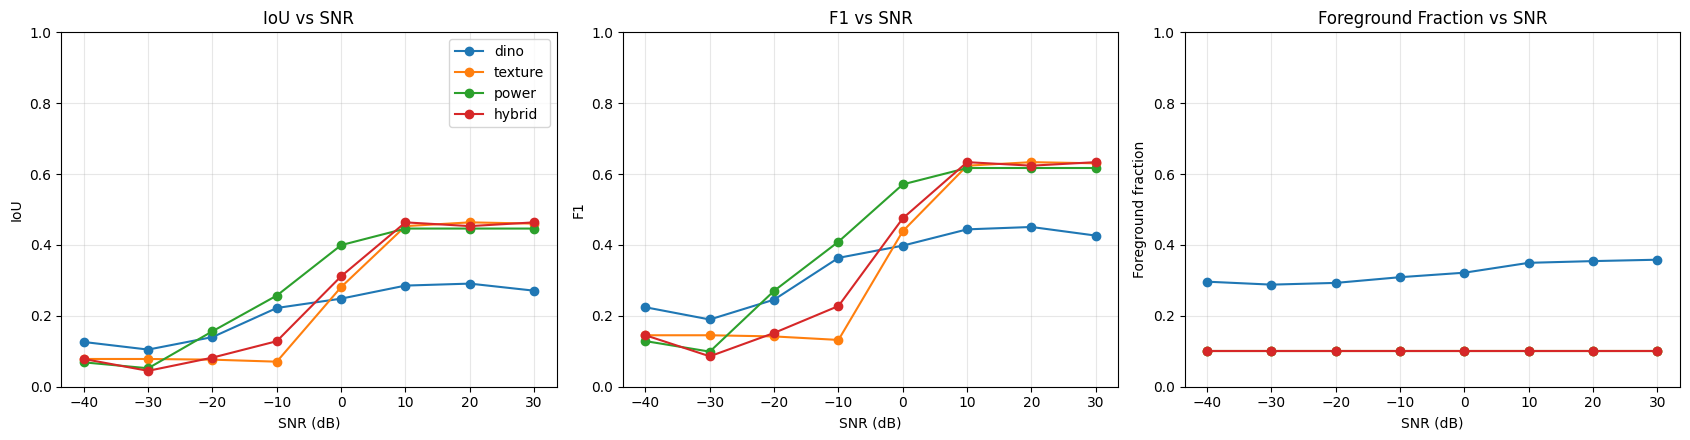

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for method in ['dino', 'texture', 'power', 'hybrid']:
    ax[0].plot(snr_eval_df['snr_db'], snr_eval_df[f'{method}_iou'], marker='o', label=method)
    ax[1].plot(snr_eval_df['snr_db'], snr_eval_df[f'{method}_f1'], marker='o', label=method)
    ax[2].plot(snr_eval_df['snr_db'], snr_eval_df[f'{method}_foreground_fraction'], marker='o', label=method)

ax[0].set_title('IoU vs SNR')
ax[0].set_xlabel('SNR (dB)')
ax[0].set_ylabel('IoU')
ax[0].set_ylim(0.0, 1.0)
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].set_title('F1 vs SNR')
ax[1].set_xlabel('SNR (dB)')
ax[1].set_ylabel('F1')
ax[1].set_ylim(0.0, 1.0)
ax[1].grid(True, alpha=0.3)

ax[2].set_title('Foreground Fraction vs SNR')
ax[2].set_xlabel('SNR (dB)')
ax[2].set_ylabel('Foreground fraction')
ax[2].set_ylim(0.0, 1.0)
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


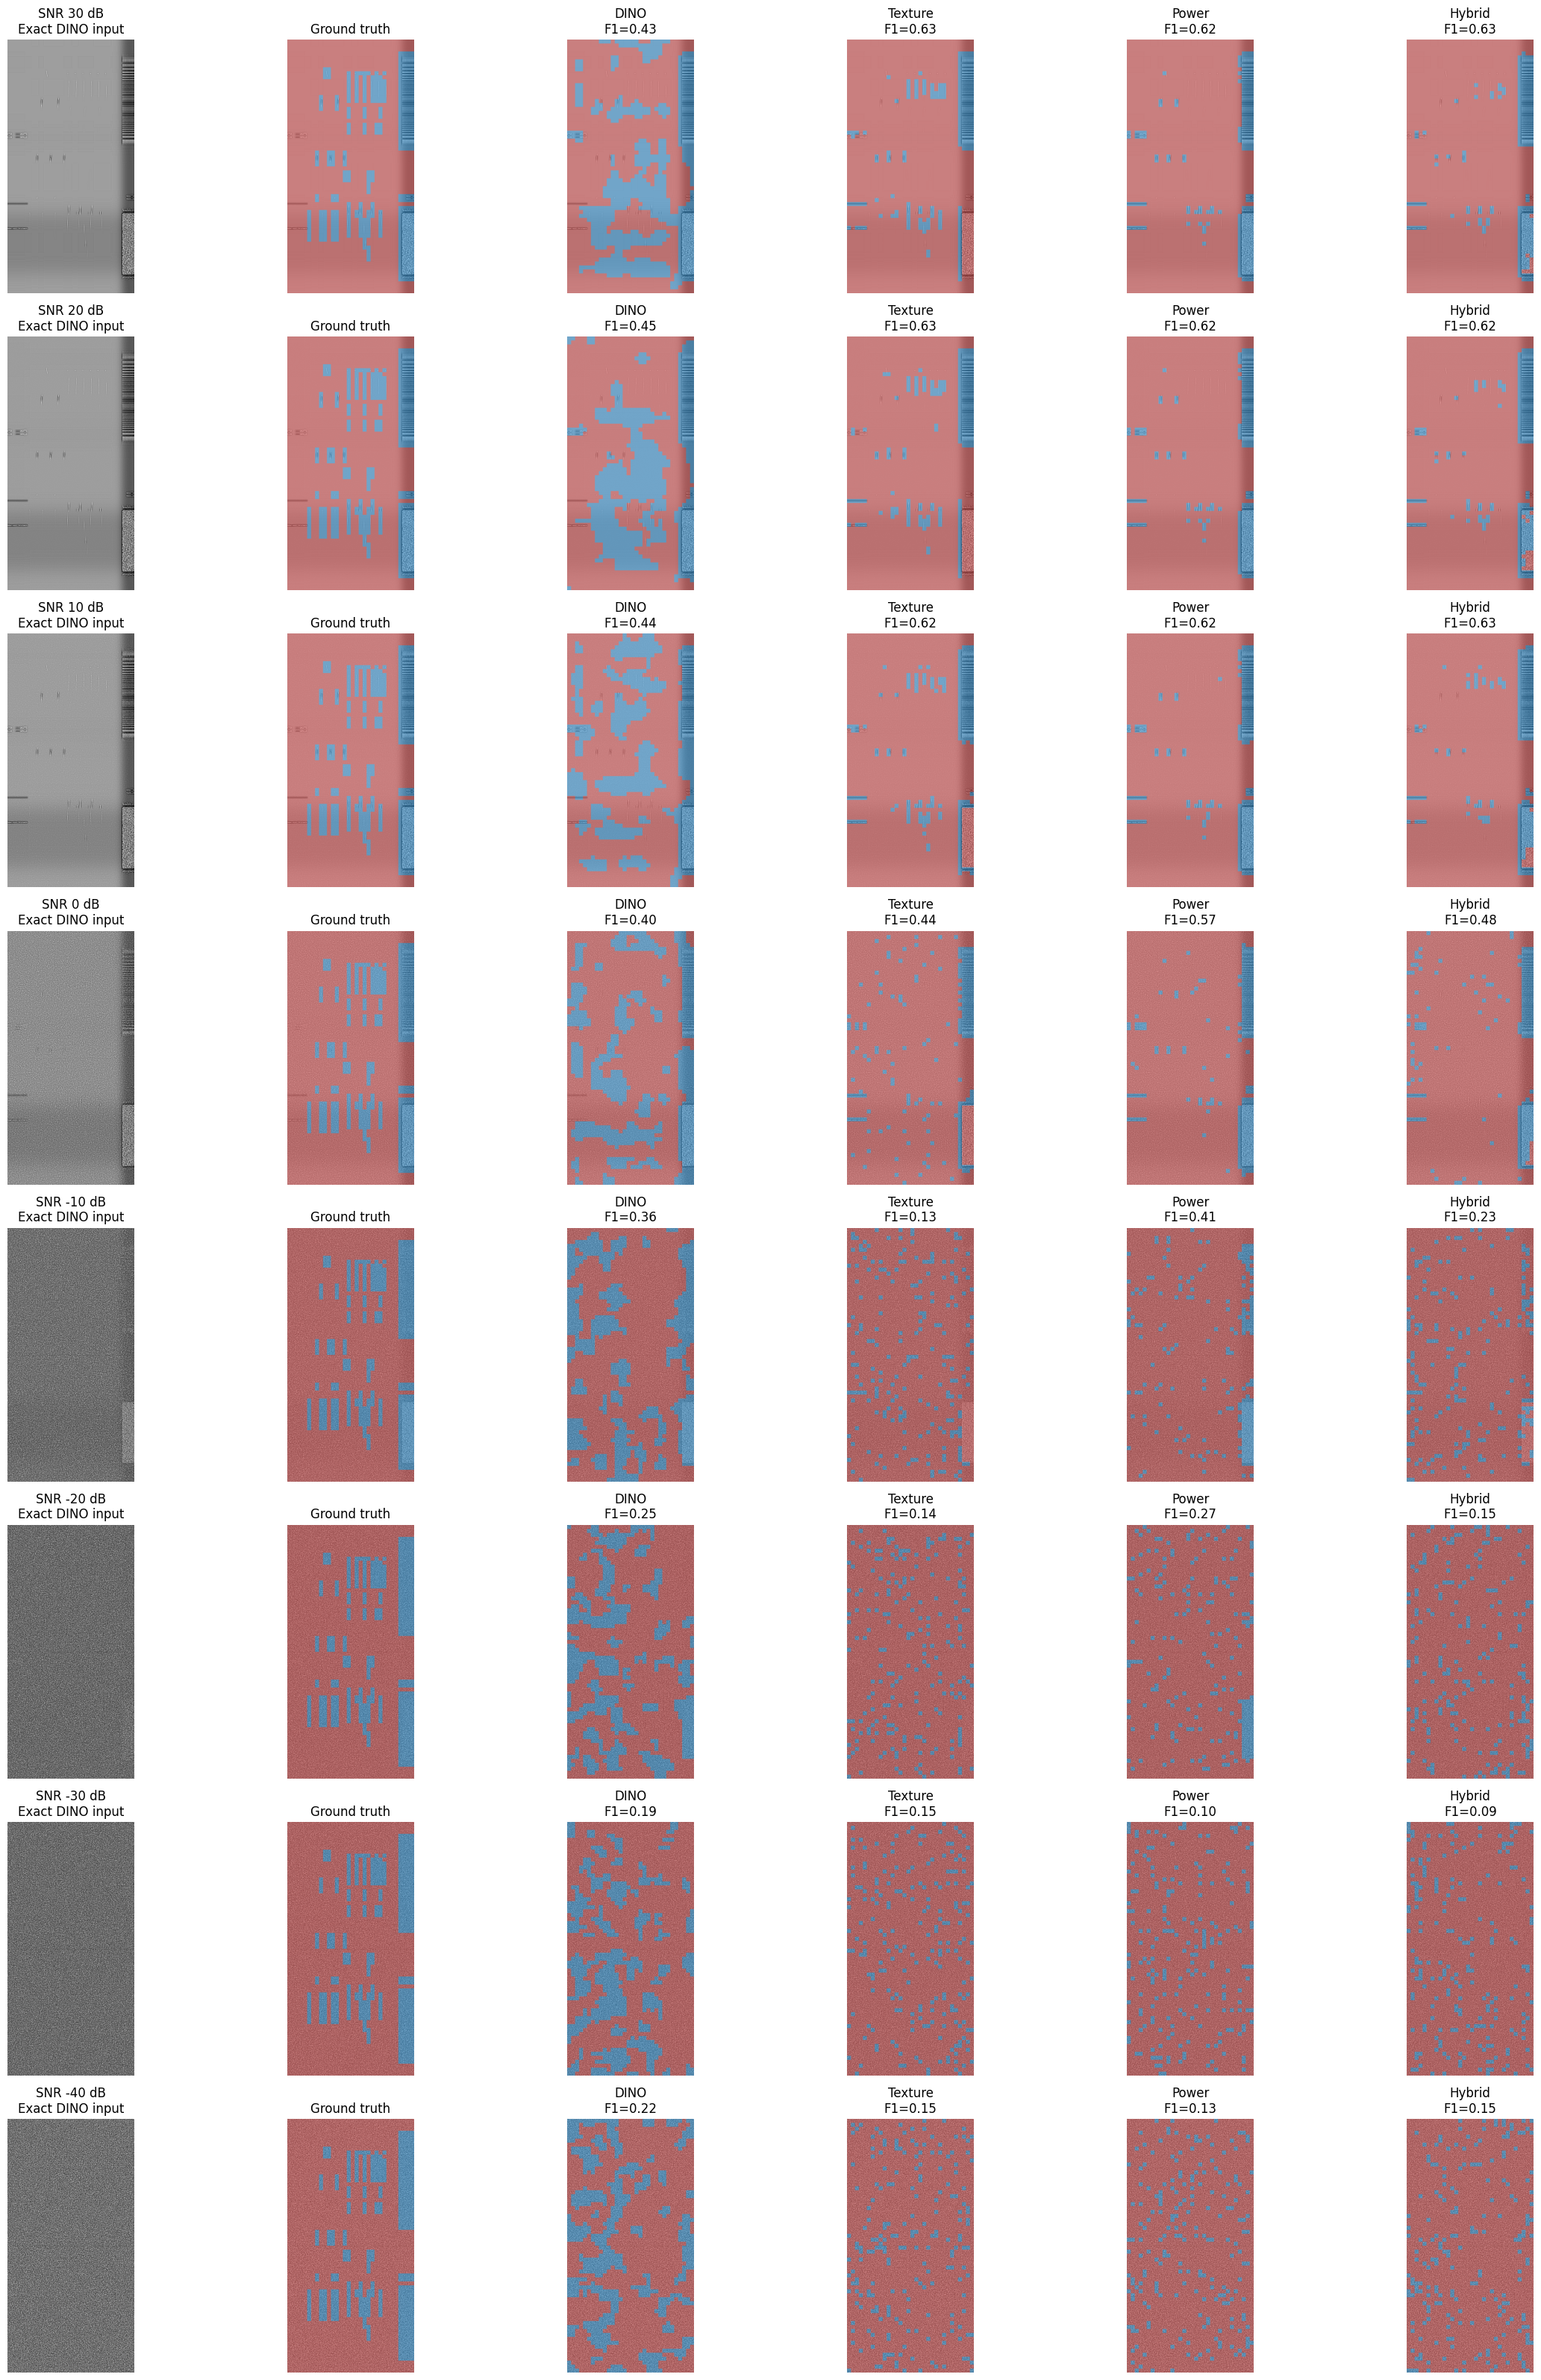

In [19]:
n = len(snr_results)
fig, axes = plt.subplots(n, 6, figsize=(24, 4.0 * n))
if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, r in enumerate(snr_results):
    ax = axes[row_idx]
    ax[0].imshow(r['spec_img'])
    ax[0].set_title(f"SNR {r['snr_db']} dB\nExact DINO input")

    ax[1].imshow(_overlay_from_mask(r['spec_img'], r['gt_mask']))
    ax[1].set_title('Ground truth')

    ax[2].imshow(_overlay_from_mask(r['spec_img'], r['dino_mask']))
    ax[2].set_title(f"DINO\nF1={r['dino_metrics']['f1']:.2f}")

    ax[3].imshow(_overlay_from_mask(r['spec_img'], r['texture_mask']))
    ax[3].set_title(f"Texture\nF1={r['texture_metrics']['f1']:.2f}")

    ax[4].imshow(_overlay_from_mask(r['spec_img'], r['power_mask']))
    ax[4].set_title(f"Power\nF1={r['power_metrics']['f1']:.2f}")

    ax[5].imshow(_overlay_from_mask(r['spec_img'], r['hybrid_mask']))
    ax[5].set_title(f"Hybrid\nF1={r['hybrid_metrics']['f1']:.2f}")

    for cur_ax in ax:
        cur_ax.axis('off')

plt.tight_layout()
plt.show()
